# Supervised Contrastive Learning vs Softmax Cross-Entropy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load and preprocess data

In [2]:
# Load and preprocess data
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
# Split into train/val
val_samples = 10000
x_val, y_val = x_train[-val_samples:], y_train[-val_samples:]
x_train, y_train = x_train[:-val_samples], y_train[:-val_samples]

In [4]:
# Datasets
batch_size = 256
train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train)).shuffle(1024).batch(batch_size)
val_ds = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)

In [5]:
# Encoder
def create_encoder():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, 3, activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
    return keras.Model(inputs, outputs, name="encoder")

# Supervised contrastive loss

In [6]:
# Supervised contrastive loss
class SupervisedContrastiveLoss(keras.losses.Loss):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.temperature = temperature

    def call(self, labels, feature_vectors):
        labels = tf.reshape(labels, [-1, 1])
        mask = tf.cast(tf.equal(labels, tf.transpose(labels)), tf.float32)

        logits = tf.matmul(feature_vectors, tf.transpose(feature_vectors)) / self.temperature
        logits_max = tf.reduce_max(logits, axis=1, keepdims=True)
        logits = logits - logits_max

        exp_logits = tf.exp(logits) * (1 - tf.eye(tf.shape(labels)[0]))
        log_prob = logits - tf.math.log(tf.reduce_sum(exp_logits, axis=1, keepdims=True) + 1e-9)

        loss = -tf.reduce_sum(mask * log_prob, axis=1) / tf.reduce_sum(mask, axis=1)
        return tf.reduce_mean(loss)

# Supervised contrastive training

In [7]:
# Supervised contrastive training
encoder = create_encoder()
contrastive_model = keras.Model(encoder.input, encoder.output)
contrastive_model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=SupervisedContrastiveLoss(temperature=0.1),
)
contrastive_model.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 4.0671 - val_loss: 3.7436
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.7187 - val_loss: 3.7044
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.6342 - val_loss: 3.6704
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.5760 - val_loss: 3.6955
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.5371 - val_loss: 3.7083
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.5061 - val_loss: 3.7075
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.4723 - val_loss: 3.7292
Epoch 8/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.4496 - val_loss: 3.7615
Epoch 9/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.4340 - val_loss: 3.7474
Epoch 10/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.4118 - val_loss: 3.7603
Epoch 11/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.3981 - val_loss: 3.7778
Epoch 12/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/ste

# Train Classifier

In [8]:
# Freeze encoder, train classifier
encoder.trainable = False
classifier_input = keras.Input(shape=(28, 28, 1))
features = encoder(classifier_input)
outputs = layers.Dense(10, activation="softmax")(features)
contrastive_classifier = keras.Model(classifier_input, outputs)
contrastive_classifier.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
contrastive_classifier.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5028 - loss: 2.1425 - val_accuracy: 0.8761 - val_loss: 1.7369
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9405 - loss: 1.5866 - val_accuracy: 0.9039 - val_loss: 1.3007
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9641 - loss: 1.1601 - val_accuracy: 0.9079 - val_loss: 0.9891
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9689 - loss: 0.8561 - val_accuracy: 0.9090 - val_loss: 0.7766
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9709 - loss: 0.6474 - val_accuracy: 0.9093 - val_loss: 0.6336
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9732 - loss: 0.5033 - val_accuracy: 0.9104 - val_loss: 0.5364
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9735 - loss: 0.4036 - val_accuracy: 0.9110 - val_loss: 0.4694
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9736 - loss: 0.3330 - val_accuracy: 0

# Train Softmax model

In [9]:
# Train Softmax model
softmax_encoder = create_encoder()
x = layers.Dense(10, activation="softmax")(softmax_encoder.output)
softmax_model = keras.Model(softmax_encoder.input, x)
softmax_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
softmax_model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7564 - loss: 1.6274 - val_accuracy: 0.8819 - val_loss: 0.9239
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8922 - loss: 0.7861 - val_accuracy: 0.8989 - val_loss: 0.5302
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9150 - loss: 0.4543 - val_accuracy: 0.9096 - val_loss: 0.3819
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9319 - loss: 0.3118 - val_accuracy: 0.9098 - val_loss: 0.3260
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9448 - loss: 0.2345 - val_accuracy: 0.9129 - val_loss: 0.2921
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9560 - loss: 0.1825 - val_accuracy: 0.9140 - val_loss: 0.2801
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9633 - loss: 0.1487 - val_accuracy: 0.9112 - val_loss: 0.2721
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9701 - loss: 0.1231 - val_accuracy: 0

# Evaluation

In [10]:
# Evaluate and visualize
contrastive_acc = contrastive_classifier.evaluate(test_ds, verbose=0)[1]
softmax_acc = softmax_model.evaluate(test_ds, verbose=0)[1]
print(f"Test Accuracy - Contrastive: {contrastive_acc:.4f}, Softmax: {softmax_acc:.4f}")

Test Accuracy - Contrastive: 0.9059, Softmax: 0.9110


# t-SNE Visualization

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


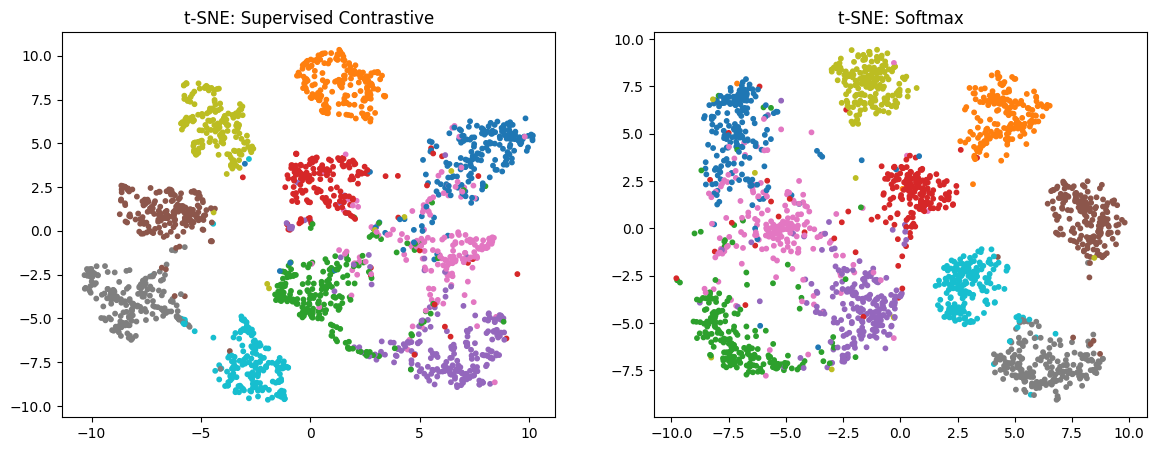

In [11]:
# t-SNE Visualization
features_contrastive = encoder.predict(x_test[:2000])
features_softmax = softmax_encoder.predict(x_test[:2000])
labels_subset = y_test[:2000]

tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
proj_contrastive = tsne.fit_transform(features_contrastive)
proj_softmax = tsne.fit_transform(features_softmax)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.title("t-SNE: Supervised Contrastive")
plt.scatter(proj_contrastive[:, 0], proj_contrastive[:, 1], c=labels_subset, cmap="tab10", s=10)
plt.subplot(1, 2, 2)
plt.title("t-SNE: Softmax")
plt.scatter(proj_softmax[:, 0], proj_softmax[:, 1], c=labels_subset, cmap="tab10", s=10)
plt.show()

# Confusion Matrix

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


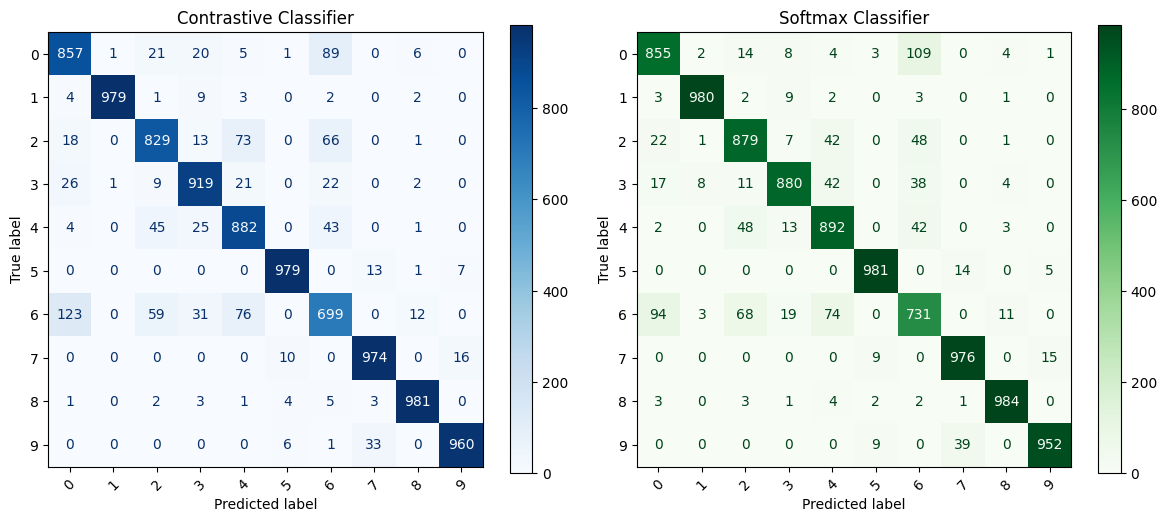

In [12]:
# Confusion Matrix
preds_contrastive = contrastive_classifier.predict(x_test).argmax(axis=1)
preds_softmax = softmax_model.predict(x_test).argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, preds_contrastive, ax=axes[0], cmap="Blues", xticks_rotation=45)
axes[0].set_title("Contrastive Classifier")
ConfusionMatrixDisplay.from_predictions(y_test, preds_softmax, ax=axes[1], cmap="Greens", xticks_rotation=45)
axes[1].set_title("Softmax Classifier")
plt.tight_layout()
plt.show()

# Visualizations for supervised contrastive learning

In [13]:
# Visual sample predictions from both models
import matplotlib.pyplot as plt
import numpy as np

In [14]:
# Show predictions for a subset of test images
def show_predictions(images, true_labels, pred_labels, title, class_names):
    plt.figure(figsize=(12, 5))
    for i in range(10):
        plt.subplot(2, 5, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        true = class_names[true_labels[i]]
        pred = class_names[pred_labels[i]]
        color = "green" if true == pred else "red"
        plt.title(f"Pred: {pred}\nTrue: {true}", color=color, fontsize=9)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [15]:
# Class names for Fashion MNIST
class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [16]:
# Get subset of predictions
subset_images = x_test[:10]
true_labels = y_test[:10]
pred_contrastive = preds_contrastive[:10]
pred_softmax = preds_softmax[:10]

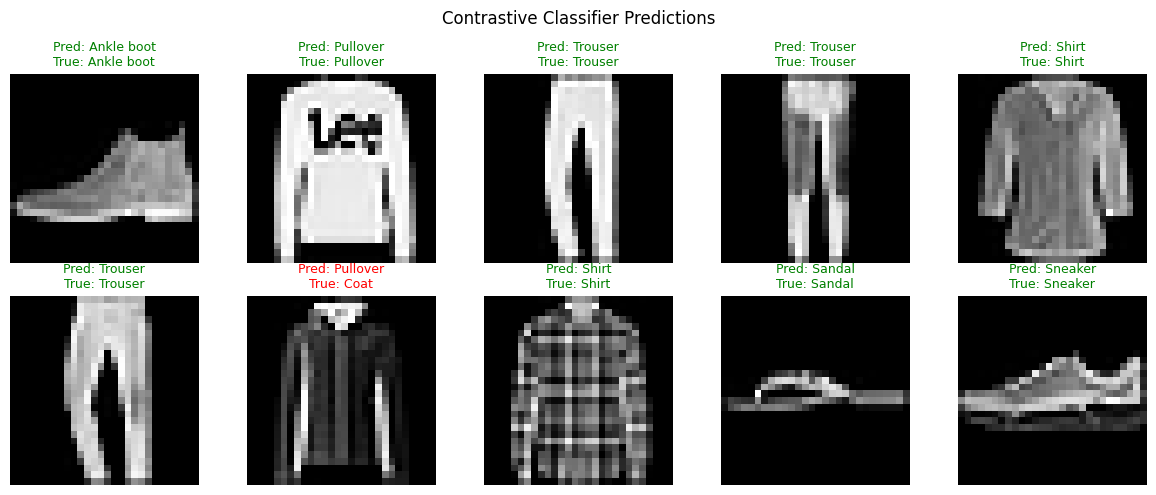

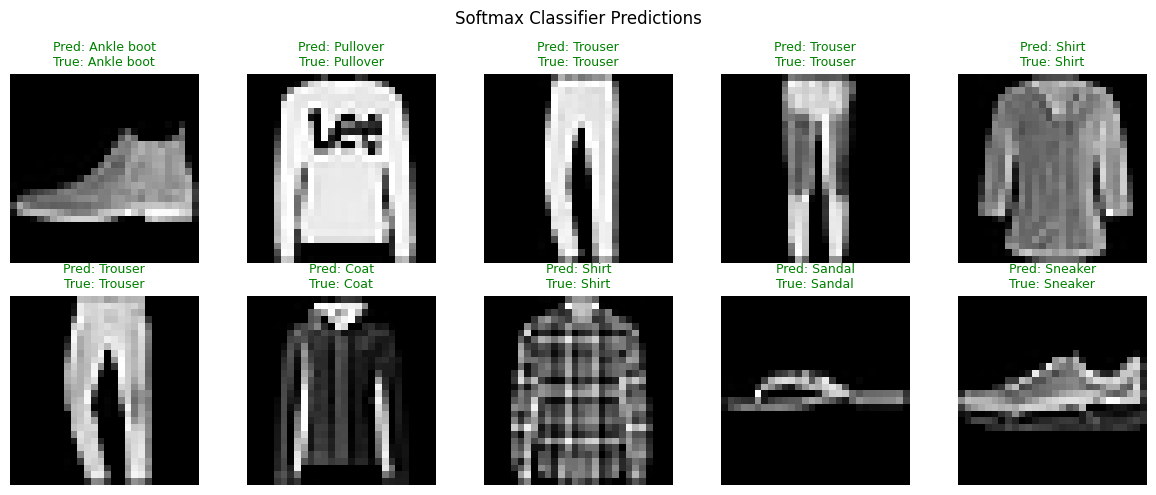

In [17]:
# Show predictions
show_predictions(subset_images, true_labels, pred_contrastive, "Contrastive Classifier Predictions", class_names)
show_predictions(subset_images, true_labels, pred_softmax, "Softmax Classifier Predictions", class_names)